# Resized Selection Analysis

This notebook loads a resized `filtered_ids`-style JSON, resolves the corresponding resized images, shows a random sample with `new_face_crop` overlays, and reports width-based summary stats.

Update `JSON_PATH` and `IMAGES_ROOT` in the next cell if your resized JSON or resized image folder lives elsewhere. `IMAGES_ROOT` must point to the directory that contains `large_dataset/...`.

In [12]:
from pathlib import Path
import json
import math
import random
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from PIL import Image, ImageOps
from IPython.display import display

RANDOM_SEED = 42
SAMPLE_SIZE = 20
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp"]

# Update these before running.
JSON_PATH = Path("filtered_ids3_adj.json")
IMAGES_ROOT = Path("large_dataset_adj")
EXPECTED_IMAGE_SIZE = (1024, 1024)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

print(f"JSON path: {JSON_PATH.resolve()}")
print(f"Images root: {IMAGES_ROOT.resolve()}")

JSON path: /home/kolyangg/rsrch/dataset_full/filtered_ids3_adj.json
Images root: /home/kolyangg/rsrch/dataset_full/large_dataset_adj


In [13]:
def find_large_dataset_root(images_root: Path) -> Path:
    images_root = images_root.resolve()
    candidate = images_root / "large_dataset"
    if candidate.is_dir():
        return candidate
    if images_root.is_dir() and images_root.name == "large_dataset":
        return images_root
    raise FileNotFoundError(
        f"Could not find a large_dataset folder under '{images_root}'. "
        "Point IMAGES_ROOT to the resized output root or directly to large_dataset/."
    )


def build_image_index(large_dataset_root: Path) -> dict[tuple[str, str], Path]:
    ext_priority = {ext: idx for idx, ext in enumerate(IMAGE_EXTENSIONS)}
    index: dict[tuple[str, str], Path] = {}

    for path in large_dataset_root.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in ext_priority:
            continue
        key = (path.parent.name, path.stem)
        existing = index.get(key)
        if existing is None:
            index[key] = path
            continue
        if ext_priority[path.suffix.lower()] < ext_priority[existing.suffix.lower()]:
            index[key] = path

    if not index:
        raise RuntimeError(f"No images found under {large_dataset_root}")
    return index


def crop_width(body_crop) -> int:
    return int(body_crop[1] - body_crop[0])


def face_width(face_crop) -> int:
    return int(face_crop[2] - face_crop[0])


def validate_image_root(image_index: dict[tuple[str, str], Path], expected_size=EXPECTED_IMAGE_SIZE, sample_size: int = 64):
    sample_paths = list(image_index.values())[:sample_size]
    if not sample_paths:
        raise RuntimeError("No images available to validate IMAGES_ROOT.")

    invalid = []
    for image_path in sample_paths:
        with Image.open(image_path) as img:
            img = ImageOps.exif_transpose(img)
            if img.size != expected_size:
                invalid.append((str(image_path), img.size))
        if len(invalid) >= 5:
            break

    if invalid:
        preview = "\n".join([f"  - {path}: {size}" for path, size in invalid])
        raise ValueError(
            "IMAGES_ROOT does not appear to point to the resized 1024x1024 images.\n"
            "Point it to the output folder created by update_filtered_ids_from_resized_selection.py.\n"
            f"Examples:\n{preview}"
        )


def load_analysis_df(json_path: Path, image_index: dict[tuple[str, str], Path]):
    if not json_path.is_file():
        raise FileNotFoundError(f"JSON file not found: {json_path}")

    with json_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, dict):
        raise ValueError("Expected a filtered_ids-style JSON object.")

    rows = []
    missing = []
    skipped = []

    for folder, folder_records in data.items():
        if not isinstance(folder_records, dict):
            skipped.append({"folder": folder, "image_id": None, "reason": "folder_records_not_dict"})
            continue

        for image_id, meta in folder_records.items():
            image_id = str(image_id)
            if not isinstance(meta, dict):
                skipped.append({"folder": folder, "image_id": image_id, "reason": "meta_not_dict"})
                continue

            body_crop = meta.get("body_crop")
            new_face_crop = meta.get("new_face_crop")
            if not isinstance(body_crop, list) or len(body_crop) != 4:
                skipped.append({"folder": folder, "image_id": image_id, "reason": "invalid_body_crop"})
                continue
            if not isinstance(new_face_crop, list) or len(new_face_crop) != 4:
                skipped.append({"folder": folder, "image_id": image_id, "reason": "invalid_new_face_crop"})
                continue

            image_path = image_index.get((folder, image_id))
            if image_path is None:
                missing.append({"folder": folder, "image_id": image_id})
                continue

            body_crop_width = crop_width(body_crop)
            new_face_crop_width = face_width(new_face_crop)
            pct = np.nan
            if body_crop_width > 0:
                pct = new_face_crop_width / body_crop_width * 100.0

            rows.append(
                {
                    "folder": folder,
                    "image_id": image_id,
                    "image_path": str(image_path),
                    "body_crop": body_crop,
                    "new_face_crop": new_face_crop,
                    "text": meta.get("text", ""),
                    "body_crop_width": body_crop_width,
                    "new_face_crop_width": new_face_crop_width,
                    "new_face_crop_as_pct_of_body_crop": pct,
                }
            )

    analysis_df = pd.DataFrame(rows)
    missing_df = pd.DataFrame(missing)
    skipped_df = pd.DataFrame(skipped)
    return analysis_df, missing_df, skipped_df


def build_summary_table(analysis_df: pd.DataFrame) -> pd.DataFrame:
    images_per_class = analysis_df.groupby("folder").size().rename("images_per_class")
    summary_df = pd.DataFrame(
        {
            "min": [
                float(images_per_class.min()),
                float(analysis_df["body_crop_width"].min()),
                float(analysis_df["new_face_crop_width"].min()),
                float(analysis_df["new_face_crop_as_pct_of_body_crop"].min()),
            ],
            "mean": [
                float(images_per_class.mean()),
                float(analysis_df["body_crop_width"].mean()),
                float(analysis_df["new_face_crop_width"].mean()),
                float(analysis_df["new_face_crop_as_pct_of_body_crop"].mean()),
            ],
            "median": [
                float(images_per_class.median()),
                float(analysis_df["body_crop_width"].median()),
                float(analysis_df["new_face_crop_width"].median()),
                float(analysis_df["new_face_crop_as_pct_of_body_crop"].median()),
            ],
            "max": [
                float(images_per_class.max()),
                float(analysis_df["body_crop_width"].max()),
                float(analysis_df["new_face_crop_width"].max()),
                float(analysis_df["new_face_crop_as_pct_of_body_crop"].max()),
            ],
        },
        index=[
            "images_per_class",
            "body_crop_width",
            "new_face_crop_width",
            "new_face_crop_as_pct_of_body_crop",
        ],
    )
    return summary_df.round(2)

In [14]:
large_dataset_root = find_large_dataset_root(IMAGES_ROOT)
image_index = build_image_index(large_dataset_root)
validate_image_root(image_index)
analysis_df, missing_df, skipped_df = load_analysis_df(JSON_PATH, image_index)

print(f"Resolved image root: {large_dataset_root}")
print(f"Indexed image files: {len(image_index):,}")
print(f"Images found for JSON entries: {len(analysis_df):,}")
print(f"Missing image files for JSON entries: {len(missing_df):,}")
print(f"Skipped JSON entries: {len(skipped_df):,}")

if not missing_df.empty:
    display(missing_df.head(10))
if not skipped_df.empty:
    display(skipped_df.head(10))

analysis_df.head(3)

Resolved image root: /home/kolyangg/rsrch/dataset_full/large_dataset_adj/large_dataset
Indexed image files: 47,500
Images found for JSON entries: 47,500
Missing image files for JSON entries: 0
Skipped JSON entries: 0


,folder,image_id,image_path,body_crop,new_face_crop,text,body_crop_width,new_face_crop_width,new_face_crop_as_pct_of_body_crop
0,dawn_chen,8,/home/kolyangg/rsrch/dataset_full/large_datase...,"[0, 1024, 0, 1024]","[398, 87, 724, 514]",A person img with shoulder-length brown hair a...,1024,326,31.835938
1,dawn_chen,10,/home/kolyangg/rsrch/dataset_full/large_datase...,"[0, 1024, 0, 1024]","[458, 114, 714, 465]",A person img with shoulder-length dark hair an...,1024,256,25.000000
2,dawn_chen,5,/home/kolyangg/rsrch/dataset_full/large_datase...,"[0, 1024, 0, 1024]","[347, 110, 502, 321]","A person img with short brown hair, wearing a ...",1024,155,15.136719


In [15]:
if analysis_df.empty:
    raise ValueError("No valid images were resolved from the JSON and image root.")

summary_stats_df = build_summary_table(analysis_df)

print(f"Images found: {len(analysis_df):,}")
print(f"Classes represented: {analysis_df['folder'].nunique():,}")
display(summary_stats_df)

Images found: 47,500
Classes represented: 2,561


,min,mean,median,max
images_per_class,5.00,18.55,18.0,30.00
body_crop_width,1024.00,1024.00,1024.0,1024.00
new_face_crop_width,61.00,281.68,255.0,962.00
new_face_crop_as_pct_of_body_crop,5.96,27.51,24.9,93.95


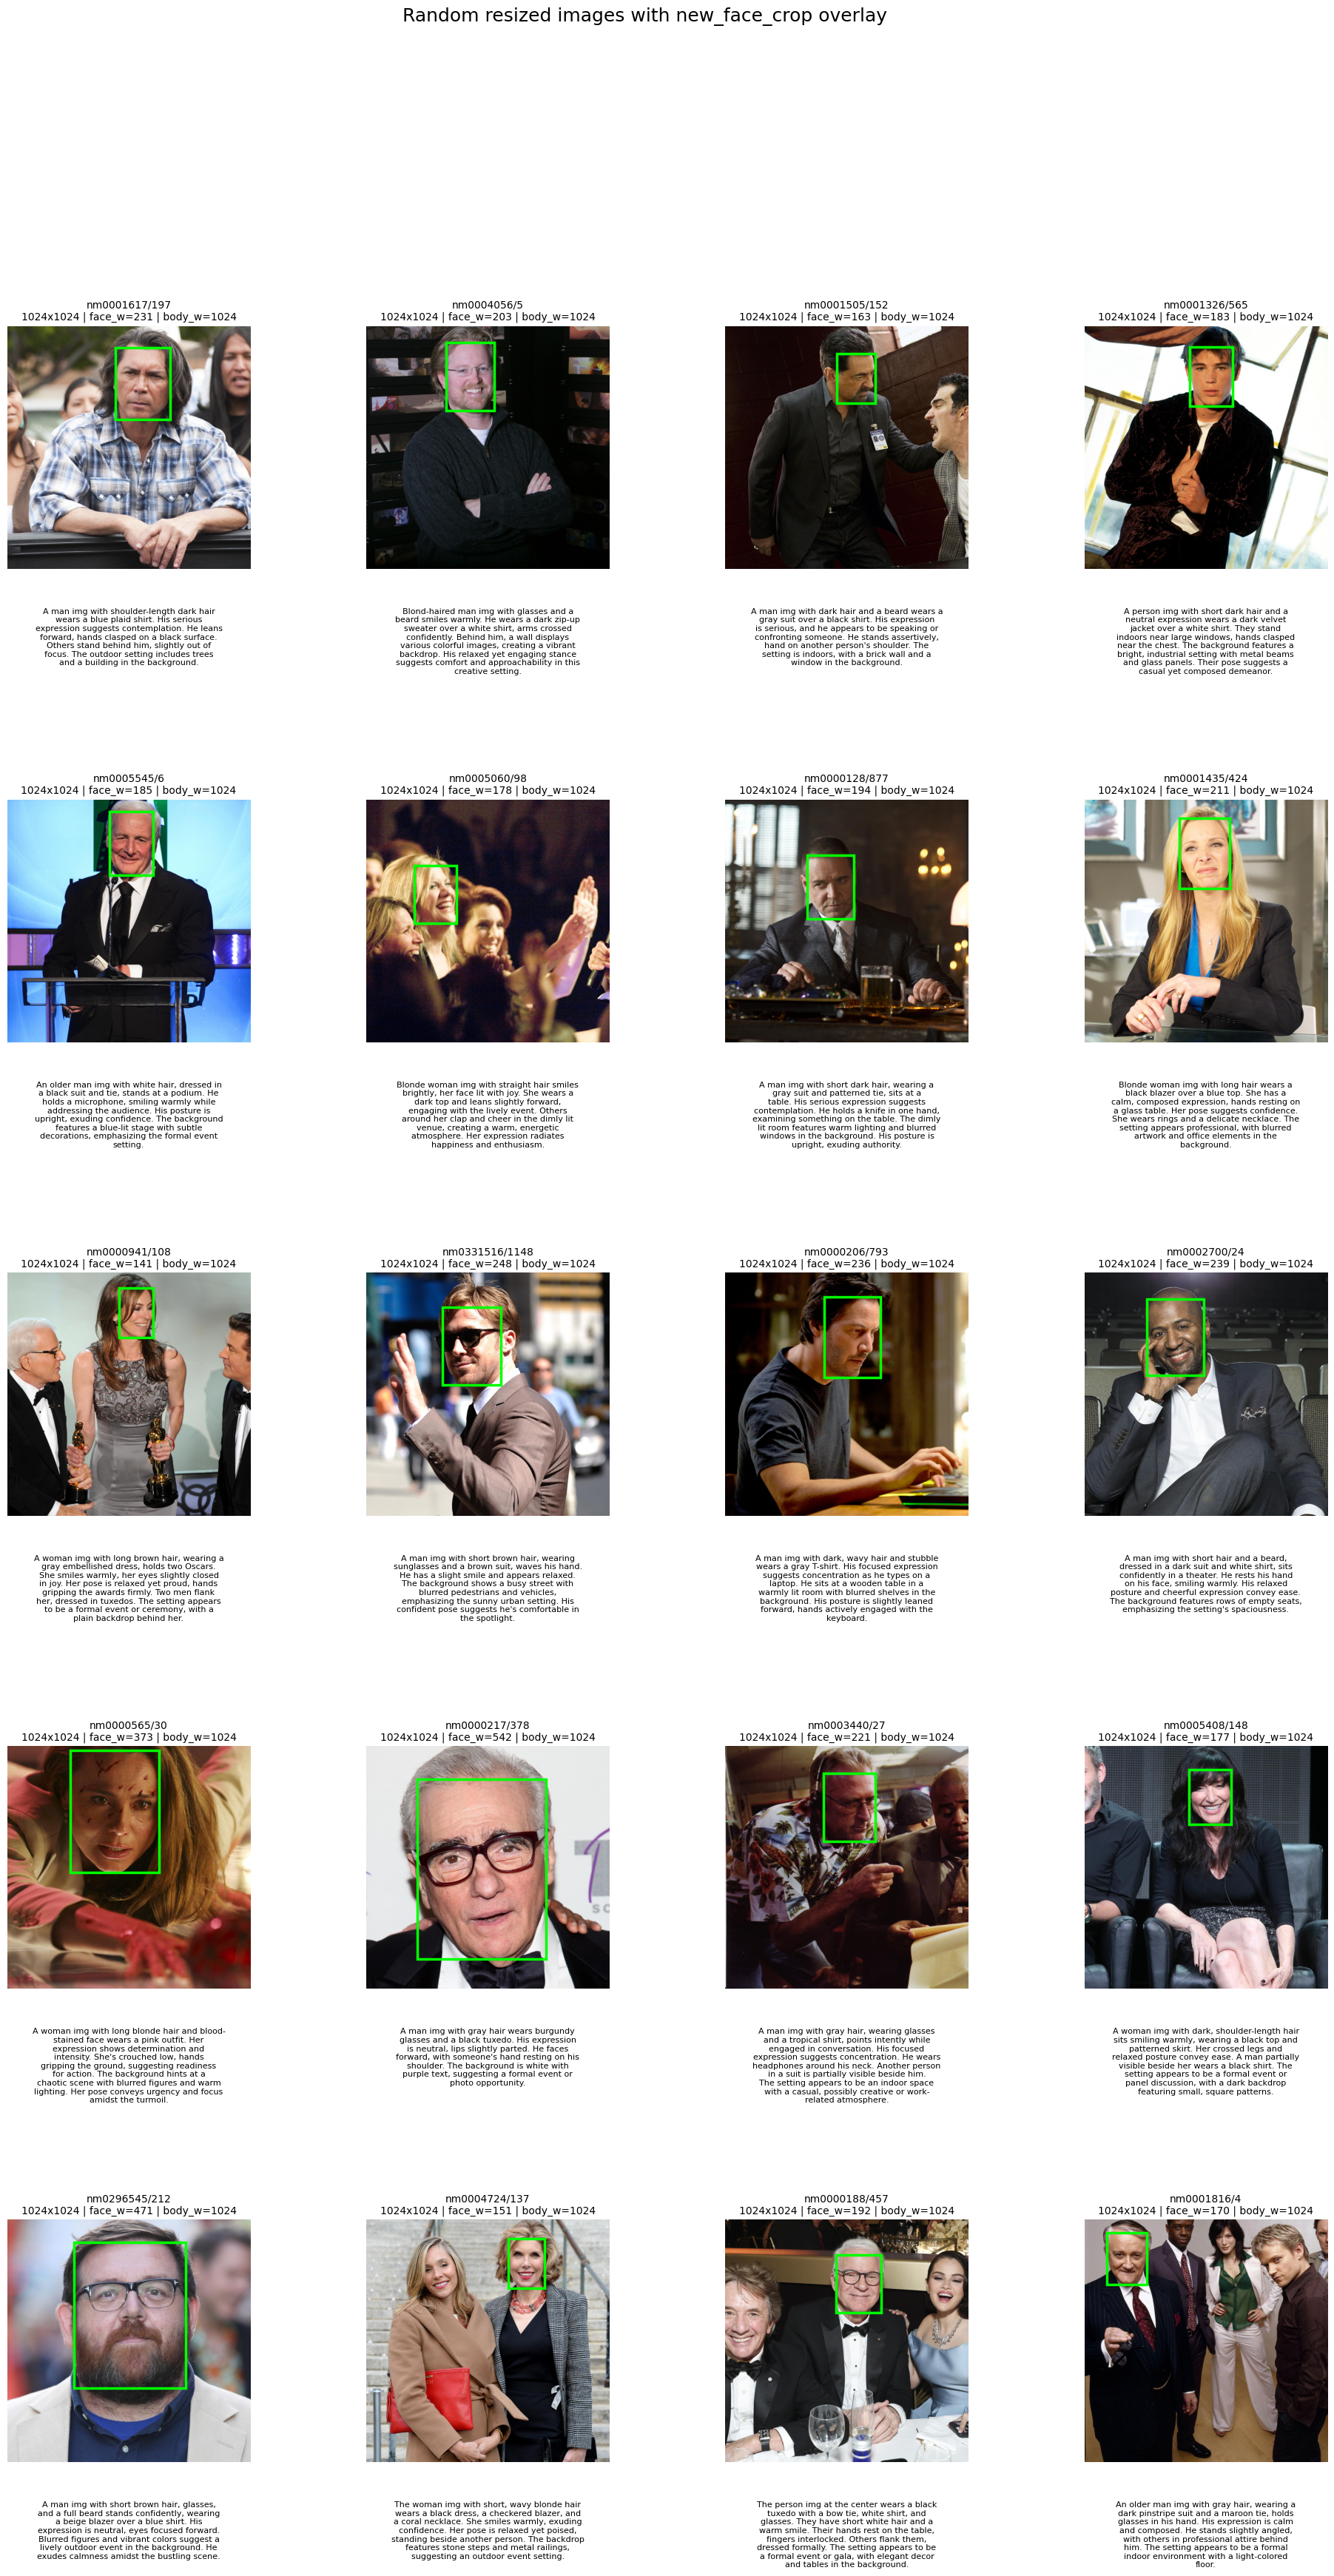

In [16]:
sample_n = min(SAMPLE_SIZE, len(analysis_df))
sample_df = analysis_df.sample(n=sample_n, random_state=RANDOM_SEED).reset_index(drop=True)

cols = 4
rows = math.ceil(sample_n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 7.5))
axes = np.atleast_1d(axes).ravel()

for ax in axes:
    ax.axis("off")

for ax, row in zip(axes, sample_df.itertuples(index=False)):
    image_path = Path(row.image_path)
    with Image.open(image_path) as img:
        img = ImageOps.exif_transpose(img).convert("RGB")
        width, height = img.size
        ax.imshow(img)

    x0, y0, x1, y1 = row.new_face_crop
    rect = Rectangle(
        (x0, y0),
        max(1, x1 - x0),
        max(1, y1 - y0),
        linewidth=2.5,
        edgecolor="lime",
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.set_title(
        f"{row.folder}/{row.image_id}\n{width}x{height} | face_w={row.new_face_crop_width} | body_w={row.body_crop_width}",
        fontsize=10,
    )

    caption = textwrap.fill(str(row.text), width=44)
    ax.text(
        0.5,
        -0.16,
        caption,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=8,
        clip_on=False,
    )

for ax in axes[len(sample_df):]:
    ax.axis("off")

fig.suptitle("Random resized images with new_face_crop overlay", fontsize=18, y=0.995)
plt.subplots_adjust(hspace=0.95, wspace=0.2)
plt.show()

In [17]:
MIN_NEW_FACE_CROP_AS_PCT_OF_BODY_CROP = 25.0

filtered_analysis_df = analysis_df[
    analysis_df["new_face_crop_as_pct_of_body_crop"] >= MIN_NEW_FACE_CROP_AS_PCT_OF_BODY_CROP
].copy()

print(f"Min new_face_crop_as_pct_of_body_crop: {MIN_NEW_FACE_CROP_AS_PCT_OF_BODY_CROP:.2f}")
print(f"Images found after filter: {len(filtered_analysis_df):,}")
print(f"Classes represented after filter: {filtered_analysis_df['folder'].nunique():,}")

if filtered_analysis_df.empty:
    print("No images satisfy the threshold.")
else:
    filtered_summary_stats_df = build_summary_table(filtered_analysis_df)
    display(filtered_summary_stats_df)


Min new_face_crop_as_pct_of_body_crop: 25.00
Images found after filter: 23,673
Classes represented after filter: 2,522


,min,mean,median,max
images_per_class,1.0,9.39,8.00,30.00
body_crop_width,1024.0,1024.00,1024.00,1024.00
new_face_crop_width,256.0,377.84,361.00,962.00
new_face_crop_as_pct_of_body_crop,25.0,36.90,35.25,93.95
